## Basic data preprocessing and cleaning

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns


import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")

print("Path to dataset files:", path)

Path to dataset files: /Users/arpitalonakadi/.cache/kagglehub/datasets/dylanjcastillo/7k-books-with-metadata/versions/3


In [3]:
import pandas as pd

In [4]:
books_load = pd.read_csv(f"{path}/books.csv")

In [5]:
books_load

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0
6806,9788185944609,8185944601,Secrets Of The Heart,NaN,Khalil Gibran,Mysticism,http://books.google.com/books/content?id=XcrVp...,NaN,1993.0,4.08,74.0,324.0
6807,9788445074879,8445074873,Fahrenheit 451,NaN,Ray Bradbury,Book burning,NaN,NaN,2004.0,3.98,186.0,5733.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

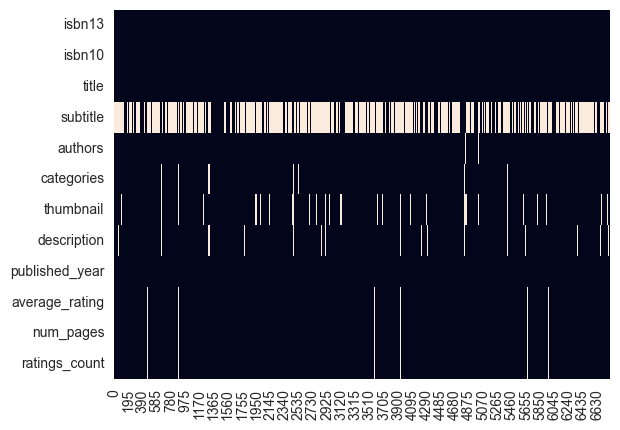

In [7]:
ax = plt.axes()
sns.heatmap(books_load.isna().transpose(), cbar=False, ax=ax)


In [8]:
# Total number of rows
total_rows = len(books_load)

# Count of missing values
missing_counts = books_load.isna().sum()

# Percentage of missing values
missing_percent = (missing_counts / total_rows * 100).round(2)

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    "Missing Values": missing_counts,
    "Percentage (%)": missing_percent
})

# Filter to show only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

print("Missing values per column:\n")
print(missing_summary)

Missing values per column:

                Missing Values  Percentage (%)
subtitle                  4429           65.04
authors                     72            1.06
categories                  99            1.45
thumbnail                  329            4.83
description                262            3.85
published_year               6            0.09
average_rating              43            0.63
num_pages                   43            0.63
ratings_count               43            0.63


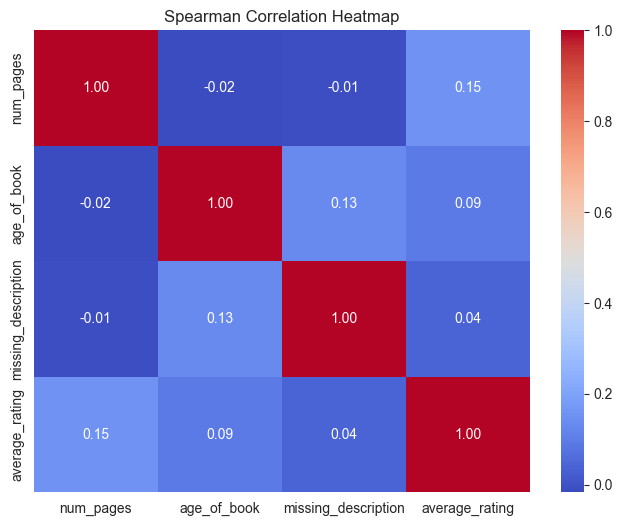

In [9]:
# Create binary flag for missing description
books_load["missing_description"] = np.where(books_load["description"].isna(), 1, 0)

# Age of book
books_load["age_of_book"] = 2024 - books_load["published_year"]

# Select columns to explore correlations
columns_of_interest = ["num_pages", "age_of_book", "missing_description", "average_rating"]
correlation_matrix = books_load[columns_of_interest].corr(method="spearman")

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Spearman Correlation Heatmap")
plt.show()

In [10]:
# Keep rows with no missing critical values
books_clean = books_load[
    ~(books_load["description"].isna()) &
    ~(books_load["num_pages"].isna()) &
    ~(books_load["average_rating"].isna()) &
    ~(books_load["published_year"].isna())
].copy()

# Count words in description
books_clean["words_in_description"] = books_clean["description"].str.split().str.len()

# Filter to keep only books with at least 20 words in description to keep it meaningful
books_clean = books_clean[books_clean["words_in_description"] >= 15].copy()

In [11]:
# Create 'title_and_subtitle' field
books_clean["title_and_subtitle"] = np.where(
    books_clean["subtitle"].isna(),
    books_clean["title"],
    books_clean[["title", "subtitle"]].astype(str).agg(": ".join, axis=1)
)

# Create 'tagged_description' field: combines ISBN and description for vector search
books_clean["tagged_description"] = books_clean[["isbn13", "description"]].astype(str).agg(" ".join, axis=1)

In [12]:
books_clean.head(20)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_book,words_in_description,title_and_subtitle,tagged_description
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0,199,Gilead,9780002005883 A NOVEL THAT READERS and critics...
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0,205,Spider's Web: A Novel,9780002261982 A new 'Christie for Christmas' -...
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,0,31.0,57,Rage of angels,"9780006178736 A memorable, mesmerizing heroine..."
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,0,22.0,45,The Four Loves,9780006280897 Lewis' work on the nature of lov...
5,9780006280934,0006280935,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0,0,22.0,75,The Problem of Pain,"9780006280934 ""In The Problem of Pain, C.S. Le..."
7,9780006380832,0006380832,Empires of the Monsoon,A History of the Indian Ocean and Its Invaders,Richard Hall,"Africa, East",http://books.google.com/books/content?id=MuPEQ...,Until Vasco da Gama discovered the sea-route t...,1998.0,4.41,608.0,65.0,0,26.0,80,Empires of the Monsoon: A History of the India...,9780006380832 Until Vasco da Gama discovered t...
8,9780006470229,000647022X,The Gap Into Madness,Chaos and Order,Stephen R. Donaldson,"Hyland, Morn (Fictitious character)",http://books.google.com/books/content?id=4oXav...,A new-cover reissue of the fourth book in the ...,1994.0,4.15,743.0,103.0,0,30.0,160,The Gap Into Madness: Chaos and Order,9780006470229 A new-cover reissue of the fourt...
9,9780006472612,0006472613,Master of the Game,NaN,Sidney Sheldon,Adventure stories,http://books.google.com/books/content?id=TkTYp...,Kate Blackwell is an enigma and one of the mos...,1982.0,4.11,489.0,43540.0,0,42.0,30,Master of the Game,9780006472612 Kate Blackwell is an enigma and ...
10,9780006479673,0006479677,If Tomorrow Comes,NaN,Sidney Sheldon,Adventure stories,http://books.google.com/books/content?id=l2tBi...,One of Sidney Sheldon's most popular and bests...,1994.0,4.04,501.0,49170.0,0,30.0,18,If Tomorrow Comes,9780006479673 One of Sidney Sheldon's most pop...
12,9780006482079,0006482074,Warhost of Vastmark,NaN,Janny Wurts,Fiction,http://books.google.com/books/content?id=uOL0f...,"Tricked once more by his wily half-brother, Ly...",1995.0,4.03,522.0,2966.0,0,29.0,136,Warhost of Vastmark,9780006482079 Tricked once more by his wily ha...


In [13]:
# Drop columns not needed anymore
books_clean.drop(
    ["subtitle", "published_year","missing_description",  "words_in_description"],
    axis=1,
    inplace=True
)

# Save to CSV
books_clean.to_csv("books_cleaned.csv", index=False)
print(" Preprocessed data saved to books_cleaned.csv")

 Preprocessed data saved to books_cleaned.csv


## Cleaning the categorical values and bucketing into fewer groups

In [14]:
books = books_clean.copy()

In [15]:
from IPython.display import display, HTML

# Your existing table
category_counts = books["categories"].value_counts(dropna=False).reset_index()
category_counts.columns = ["category", "count"]
category_counts["percentage"] = round((category_counts["count"] / len(books)) * 100, 2)
category_counts = category_counts.sort_values(by="count", ascending=False)

# Display as scrollable HTML table
display(HTML(category_counts.to_html(index=False, max_rows=50, justify="left",
                                     notebook=True, escape=False, border=0)))

category,count,percentage
Fiction,2415,39.31
Juvenile Fiction,503,8.19
Biography & Autobiography,371,6.04
History,245,3.99
Literary Criticism,149,2.43
Comics & Graphic Novels,140,2.28
Philosophy,139,2.26
Religion,133,2.16
Drama,111,1.81
Juvenile Nonfiction,99,1.61


In [16]:
books.categories.isna().sum()

33

In [17]:
# Define your custom grouping
custom_category_mapping = {
    # Fiction
    "Fiction": "Fiction",
    "Fantasy": "Fiction",
    "Science fiction": "Fiction",
    "Romance": "Fiction",
    "Thriller": "Fiction",
    "Mystery": "Fiction",
    "Horror": "Fiction",
    "Historical": "Fiction",
    "Literary Collections": "Fiction",

    # Non-Fiction
    "Biography & Autobiography": "Nonfiction",
    "Memoir": "Nonfiction",
    "History": "Nonfiction",
    "Religion": "Nonfiction",
    "Philosophy": "Nonfiction",
    "Science": "Nonfiction",
    "Self-Help": "Nonfiction",

    # Poetry and Drama
    "Poetry": "Poetry & Drama",
    "Drama": "Poetry & Drama",
    "Plays": "Poetry & Drama",
    "Theater": "Poetry & Drama",

    # Children's Books
    "Juvenile Nonfiction": "Children's Books",
    "Childrenâ€™s Nonfiction": "Children's Books",
    "Educational": "Children's Books",
    "Reference": "Children's Books",
    "Comics & Graphic Novels": "Children's Books",
    "Manga": "Children's Books",
    "Comic books": "Children's Books",
    "Illustrated fiction": "Children's Books",
   "Juvenile Fiction" : "Children's Books",

    # Business and Wellness
    "Spirituality": "Business & Wellness",
    "Inspirational": "Business & Wellness",
    "Fitness": "Business & Wellness",
    "Cooking": "Business & Wellness",
    "Mental Health": "Business & Wellness",
    "Medicine": "Business & Wellness",
    "Study Guides": "Business & Wellness",
    "Textbooks": "Business & Wellness",
    "How-To": "Business & Wellness",
    "Crafts": "Business & Wellness",
    "Business & Economics":"Business & Wellness",
     "Literary Criticism" : "Business & Wellness",
    "Social Science" : "Business & Wellness",
    "Body, Mind & Spirit" : "Business & Wellness",
    "Psychology": "Business & Wellness"
}

# Map categories to super categories
books["super_category"] = books["categories"].map(custom_category_mapping)

# Check mapping distribution
super_cat_dist = books["super_category"].value_counts(dropna=False).reset_index()
super_cat_dist.columns = ["super_category", "count"]
super_cat_dist["percentage"] = round((super_cat_dist["count"] / len(books)) * 100, 2)

# Display result
from IPython.display import display, HTML
display(HTML(super_cat_dist.to_html(index=False, max_rows=50, justify="left", escape=False, border=0)))

super_category,count,percentage
Fiction,2496,40.62
NaN,1344,21.88
Nonfiction,987,16.06
Children's Books,753,12.26
Business & Wellness,386,6.28
Poetry & Drama,178,2.90


In [18]:
# Filter records where super_category is NaN
books_missing_super = books[books["super_category"].isna()].copy()

# Aggregate category counts for these records
category_breakdown = books_missing_super["categories"].value_counts().reset_index()
category_breakdown.columns = ["category", "count"]

# Show category-wise distribution
print("📊 Category breakdown for books with missing super_category:")
display(category_breakdown)

📊 Category breakdown for books with missing super_category:


,category,count
0,Performing Arts,48
1,Art,42
2,Travel,42
3,Computers,36
4,Political Science,34
...,...,...
485,Paris (France),1
486,Autonomy (Psychology).,1
487,Bombings,1
488,India,1


In [19]:
from transformers import pipeline
from tqdm import tqdm
import numpy as np

# Initialize pipeline (use device=0 for GPU if available)
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=-1)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [70]:
pip install torch

  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/b3/17/41f681b87290a1d2f1394f943e470f8b0b3c2987b7df8dc078d8831fce5b/torch-2.6.0-cp39-none-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for networkx from https://files.pythonhosted.org/packages/d5/f0/8fbc882ca80cf077f1b246c0e3c3465f7f415439bdea6b899f6b19f61f70/networkx-3.2.1-py3-none-any.whl.metadata
  Obtaining dependency information for sympy==1.13.1 from https://files.pythonhosted.org/packages/b2/fe/81695a1aa331a842b582453b605175f419fe8540355886031328089d840a/sympy-1.13.1-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 MB 32.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 38.6 MB/s eta 0:00:0000:0100:01
Using cached networkx-3.2.1-py3-none-any.whl (1.6 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:
      Successfully uninstalled sympy-1.13.3

[no

In [20]:
pip install --upgrade torch transformers


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install --upgrade torch==2.2.1 transformers==4.38.2

Note: you may need to restart the kernel to use updated packages.


In [20]:

# Define labels
labels = ["Fiction", "Nonfiction"]

# Filter only rows with missing super_category
books_missing = books[books["super_category"].isna()].copy()


In [21]:

# Classify descriptions
predicted = []
for desc in tqdm(books_missing["description"]):
    result = classifier(desc, labels)
    predicted.append(result["labels"][np.argmax(result["scores"])])

books_missing["super_category"] = predicted
books.update(books_missing)

100%|██████████| 1344/1344 [08:01<00:00,  2.79it/s]


In [28]:
# Step 1: Keep only isbn13 and predicted super_category
predicted_df = books_missing[["isbn13", "super_category"]].copy()
predicted_df.rename(columns={"super_category": "predicted_super_category"}, inplace=True)

In [29]:

# Step 2: Left join with original books DataFrame
books = books.merge(predicted_df, on="isbn13", how="left")

In [30]:

# Step 3: Fill only missing super_category with predicted values
books["super_category"] = np.where(
    books["super_category"].isna(),
    books["predicted_super_category"],
    books["super_category"]
)

In [31]:

# Step 4: Drop helper column
books.drop(columns=["predicted_super_category"], inplace=True)


In [32]:
# Step 5: Final check
print("✅ Remaining nulls in super_category:", books["super_category"].isna().sum())

✅ Remaining nulls in super_category: 0


In [34]:
# Step 6: Display final distribution
final_dist = books["super_category"].value_counts(dropna=False).reset_index()
final_dist.columns = ["super_category", "count"]
final_dist["percentage"] = round((final_dist["count"] / len(books)) * 100, 2)

from IPython.display import display, HTML
display(HTML(final_dist.to_html(index=False, max_rows=50, justify="left", escape=False, border=0)))

super_category,count,percentage
Fiction,2966,48.27
Nonfiction,1861,30.29
Children's Books,753,12.26
Business & Wellness,386,6.28
Poetry & Drama,178,2.90


In [35]:
books.to_csv("books_final_preprocessed.csv", index=False)
print("Final preprocessed DataFrame saved as 'books_final_preprocessed.csv'")

Final preprocessed DataFrame saved as 'books_final_preprocessed.csv'


## Adding Emotion and sentiment scope to the descriptions

In [36]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import pipeline

# Load your preprocessed dataset
books = pd.read_csv("books_final_preprocessed.csv")

In [37]:

# Initialize emotion classifier
classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    device=-1  # Change to device=0 if you have a GPU
)

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [38]:
# Define emotion labels
emotion_labels = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]

# Helper to extract max emotion scores across all sentences
def calculate_max_emotion_scores(predictions):
    per_emotion_scores = {label: [] for label in emotion_labels}
    for prediction in predictions:
        sorted_predictions = sorted(prediction, key=lambda x: x["label"])
        for index, label in enumerate(emotion_labels):
            per_emotion_scores[label].append(sorted_predictions[index]["score"])
    return {label: np.max(scores) for label, scores in per_emotion_scores.items()}


In [39]:
# Process each book description
isbn = []
emotion_scores = {label: [] for label in emotion_labels}

for i in tqdm(range(len(books))):
    isbn.append(books["isbn13"][i])
    sentences = books["description"][i].split(".")
    predictions = classifier(sentences)
    max_scores = calculate_max_emotion_scores(predictions)
    for label in emotion_labels:
        emotion_scores[label].append(max_scores[label])

100%|██████████| 6144/6144 [14:46<00:00,  6.93it/s]   


In [40]:
# Create emotion DataFrame
emotions_df = pd.DataFrame(emotion_scores)
emotions_df["isbn13"] = isbn


In [41]:

# Merge with original books dataset
books = pd.merge(books, emotions_df, on="isbn13")

# Save final dataset with emotion scores
books.to_csv("books_with_emotions.csv", index=False)

print(" Emotion-enriched dataset saved as 'books_with_emotions.csv'")

 Emotion-enriched dataset saved as 'books_with_emotions.csv'


In [42]:

# Load final dataset
books = pd.read_csv("books_with_emotions.csv")

# Show first few rows
print("📚 Sample rows from books_with_emotions.csv")
display(books.head())

# Check for missing values
print("\n🔍 Missing values per column:")
print(books.isna().sum())

# Emotion columns
emotion_labels = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]

# For each book, find which emotion is strongest
books["dominant_emotion"] = books[emotion_labels].idxmax(axis=1)

# Count how many books fall under each dominant emotion
emotion_counts = books["dominant_emotion"].value_counts().reset_index()
emotion_counts.columns = ["emotion", "count"]

print("\n📊 Number of books per dominant emotion:")
display(emotion_counts)

📚 Sample rows from books_with_emotions.csv


,isbn13,isbn10,title,authors,categories,thumbnail,description,average_rating,num_pages,ratings_count,...,title_and_subtitle,tagged_description,super_category,anger,disgust,fear,joy,sadness,surprise,neutral
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,3.85,247.0,361.0,...,Gilead,9780002005883 A NOVEL THAT READERS and critics...,Fiction,0.064134,0.273591,0.928169,0.932798,0.646215,0.967158,0.729603
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,3.83,241.0,5164.0,...,Spider's Web: A Novel,9780002261982 A new 'Christie for Christmas' -...,Fiction,0.612618,0.348286,0.942528,0.704423,0.887940,0.111690,0.252546
2,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",3.93,512.0,29532.0,...,Rage of angels,"9780006178736 A memorable, mesmerizing heroine...",Fiction,0.064134,0.104007,0.972321,0.767238,0.549476,0.111690,0.078766
3,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,4.15,170.0,33684.0,...,The Four Loves,9780006280897 Lewis' work on the nature of lov...,Nonfiction,0.351483,0.150723,0.360706,0.251882,0.732686,0.111690,0.078766
4,9780006280934,0006280935,The Problem of Pain,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",4.09,176.0,37569.0,...,The Problem of Pain,"9780006280934 ""In The Problem of Pain, C.S. Le...",Nonfiction,0.081412,0.184495,0.095043,0.040565,0.884390,0.475880,0.078766



🔍 Missing values per column:
isbn13                  0
isbn10                  0
title                   0
authors                55
categories             33
thumbnail             202
description             0
average_rating          0
num_pages               0
ratings_count           0
age_of_book             0
title_and_subtitle      0
tagged_description      0
super_category          0
anger                   0
disgust                 0
fear                    0
joy                     0
sadness                 0
surprise                0
neutral                 0
dtype: int64

📊 Number of books per dominant emotion:


,emotion,count
0,sadness,3773
1,fear,854
2,joy,612
3,surprise,348
4,disgust,262
5,anger,193
6,neutral,102


## Creating thr recommendation function and also the vector databsse

In [43]:
# 1. Imports
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
import pandas as pd
from dotenv import load_dotenv

In [54]:

# 2. Load environment (for OpenAI API key)
from dotenv import load_dotenv
load_dotenv()

# 3. Load your final dataframe
books = pd.read_csv("books_with_emotions.csv")

In [50]:

# 4. Save tagged_description column to text file (required for LangChain loader)
books["tagged_description"].to_csv("tagged_description.txt", sep="\n", index=False, header=False)


In [51]:

# 5. Load text as LangChain documents
raw_documents = TextLoader("tagged_description.txt").load()


In [52]:

# 6. Split documents
text_splitter = CharacterTextSplitter(chunk_size=0, chunk_overlap=0, separator="\n")
documents = text_splitter.split_documents(raw_documents)


Created a chunk of size 1168, which is longer than the specified 0
Created a chunk of size 1214, which is longer than the specified 0
Created a chunk of size 373, which is longer than the specified 0
Created a chunk of size 309, which is longer than the specified 0
Created a chunk of size 483, which is longer than the specified 0
Created a chunk of size 482, which is longer than the specified 0
Created a chunk of size 960, which is longer than the specified 0
Created a chunk of size 188, which is longer than the specified 0
Created a chunk of size 128, which is longer than the specified 0
Created a chunk of size 843, which is longer than the specified 0
Created a chunk of size 296, which is longer than the specified 0
Created a chunk of size 197, which is longer than the specified 0
Created a chunk of size 881, which is longer than the specified 0
Created a chunk of size 1088, which is longer than the specified 0
Created a chunk of size 1189, which is longer than the specified 0
Create

In [55]:

# 7. Create vector store
db_books = Chroma.from_documents(documents, embedding=OpenAIEmbeddings())


In [56]:

# 8. Define semantic search function
def retrieve_semantic_recommendations(query: str, top_k: int = 10) -> pd.DataFrame:
    results = db_books.similarity_search(query, k=top_k)
    isbns = [int(doc.page_content.split()[0].strip('"')) for doc in results]
    return books[books["isbn13"].isin(isbns)]

In [57]:

# 9. Example usage
recommendations = retrieve_semantic_recommendations("A book to teach children about nature", top_k=10)
print(recommendations[["title", "authors", "categories", "description"]])

                                                  title  \
2005               Tsunamis and Other Natural Disasters   
3817                                Moo, Baa, la la La!   
4215                                       It's Winter!   
4424                Baby Einstein: Neighborhood Animals   
4425                               Baby Einstein: Birds   
4426                              Baby Einstein: Babies   
4427                                Baby Einstein: Dogs   
4428  Baby Einstein: What Does Violet See? Raindrops...   
4449     Disney's Little Einsteins: Music of the Meadow   
4486                                               Tree   

                                   authors           categories  \
2005  Mary Pope Osborne;Natalie Pope Boyce  Juvenile Nonfiction   
3817                        Sandra Boynton        Animal sounds   
4215                          Linda Glaser  Juvenile Nonfiction   
4424     Marilyn Singer;Julie Aigner-Clark     Juvenile Fiction   
4425           